## Задание 1. (1 балл)

Посчитайте частоты для 5-грамм в корпусе lenta.txt. двумя способами:  
1) Текст токенизируется в один сплошной список токенов и нграммы считаются по всем токенам без учета границ предложений
2) Текст разбивается на предложения, а каждое предложение на токены; нграммы собираются с учетом границ предложений 
    
Найдите различия между топ 100 нграммов для первого и второго способов

In [1]:
import nltk
nltk.download('punkt_tab')
from nltk import sent_tokenize
from nltk.tokenize import word_tokenize
import regex as re
from tqdm import tqdm
from nltk.util import ngrams
from collections import Counter
from itertools import chain
import math


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\katyk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
with open (r'C:\\Users\\katyk\\OneDrive\\Рабочий стол\\lenta.txt', encoding = 'utf-8') as f:
    corpus = f.read()

### Без деления на предложения

Я не буду убирать стоп-слова, мне кажется, для выделения н-грамм их довольно осмысленно оставлять.

In [3]:
tokens = word_tokenize(corpus) # токены
tokens = [token.lower() for token in tqdm(tokens) if re.fullmatch(r'\w+', token)] # выбрасываем мусор

n = 5
fivegrams = list(ngrams(tokens, n)) # выделение н-грамм

freq = Counter(fivegrams)
total = sum(freq.values())
top_100 = freq.most_common(100)

for gram, count in top_100:
    ipm = count / total * 1_000_000 # частотность в ipm
    print(f"{' '.join(gram)}\t{count}\t{ipm:.6f}")

100%|██████████| 1777831/1777831 [00:14<00:00, 119448.05it/s]


риа новости со ссылкой на	400	274.287470
сообщает риа новости со ссылкой	320	219.429976
как сообщили риа новости в	196	134.400860
как сообщает риа новости со	149	102.172082
сообщает интерфакс со ссылкой на	142	97.372052
об этом риа новости сообщили	113	77.486210
об этом сообщает риа новости	104	71.314742
этом риа новости сообщили в	99	67.886149
со ссылкой на источники в	93	63.771837
группировки войск на северном кавказе	84	57.600369
как сообщает интерфакс со ссылкой	83	56.914650
объединенной группировки войск на северном	83	56.914650
эхо москвы со ссылкой на	77	52.800338
этом сообщает риа новости со	75	51.428901
в связи с тем что	70	48.000307
как сообщает со ссылкой на	67	45.943151
по борьбе с организованной преступностью	66	45.257433
федеральных сил на северном кавказе	55	37.714527
об этом риа новости сообщил	54	37.028808
сообщает рбк со ссылкой на	51	34.971652
обязанности президента россии владимир путин	49	33.600215
помощник президента россии сергей ястржембский	45	30.857340
управле

### С делением по предложениям

In [4]:
sentences = sent_tokenize(corpus)

sent_tokens = []
for sent in tqdm(sentences):
    tok = word_tokenize(sent)
    tok = [t.lower() for t in tok if re.fullmatch(r'\w+', t)]
    sent_tokens.append(tok)

n = 5
fivegrams = []
for sent in tqdm(sent_tokens):
    fivegrams.extend(ngrams(sent, n))

freq = Counter(fivegrams)
total = sum(freq.values())
top_100 = freq.most_common(100)

for gram, count in top_100:
    ipm = count / total * 1_000_000 # частотность в ipm
    print(f"{' '.join(gram)}\t{count}\t{ipm:.6f}")

100%|██████████| 76344/76344 [00:00<00:00, 103337.70it/s]


риа новости со ссылкой на	400	346.606935
сообщает риа новости со ссылкой	320	277.285548
как сообщили риа новости в	196	169.837398
как сообщает риа новости со	149	129.111083
сообщает интерфакс со ссылкой на	142	123.045462
об этом риа новости сообщили	113	97.916459
об этом сообщает риа новости	104	90.117803
этом риа новости сообщили в	99	85.785216
со ссылкой на источники в	93	80.586112
группировки войск на северном кавказе	84	72.787456
как сообщает интерфакс со ссылкой	83	71.920939
объединенной группировки войск на северном	83	71.920939
эхо москвы со ссылкой на	76	65.855318
этом сообщает риа новости со	75	64.988800
в связи с тем что	70	60.656214
как сообщает со ссылкой на	67	58.056662
по борьбе с организованной преступностью	66	57.190144
федеральных сил на северном кавказе	55	47.658454
об этом риа новости сообщил	54	46.791936
сообщает рбк со ссылкой на	51	44.192384
обязанности президента россии владимир путин	49	42.459350
управления по борьбе с организованной	40	34.660693
передает риа но

### Разница

1. 4 n-граммы возникли на стыках предложений

* сообщает риа новости по словам	35	24.000154

* передает риа новости по словам	24	16.457248

* сообщает риа новости по данным	20	13.714373

* в по московскому времени в	19	13.028655

2. Во втором списке их нет, и их место занимают другие: 

* по борьбе с экономическими преступлениями	17	14.730795

* об этом заявил в среду	17	14.730795

* со ссылкой на правоохранительные органы	17	14.730795

* получили ранения различной степени тяжести	17	14.730795

## Задание 2. (1 балл)

Найдите какую-то инетересную (по вашему мнению) закономерность на https://books.google.com/ngrams/ для русского языка (с 1990 по 2022)

Вставьте сюда скриншот

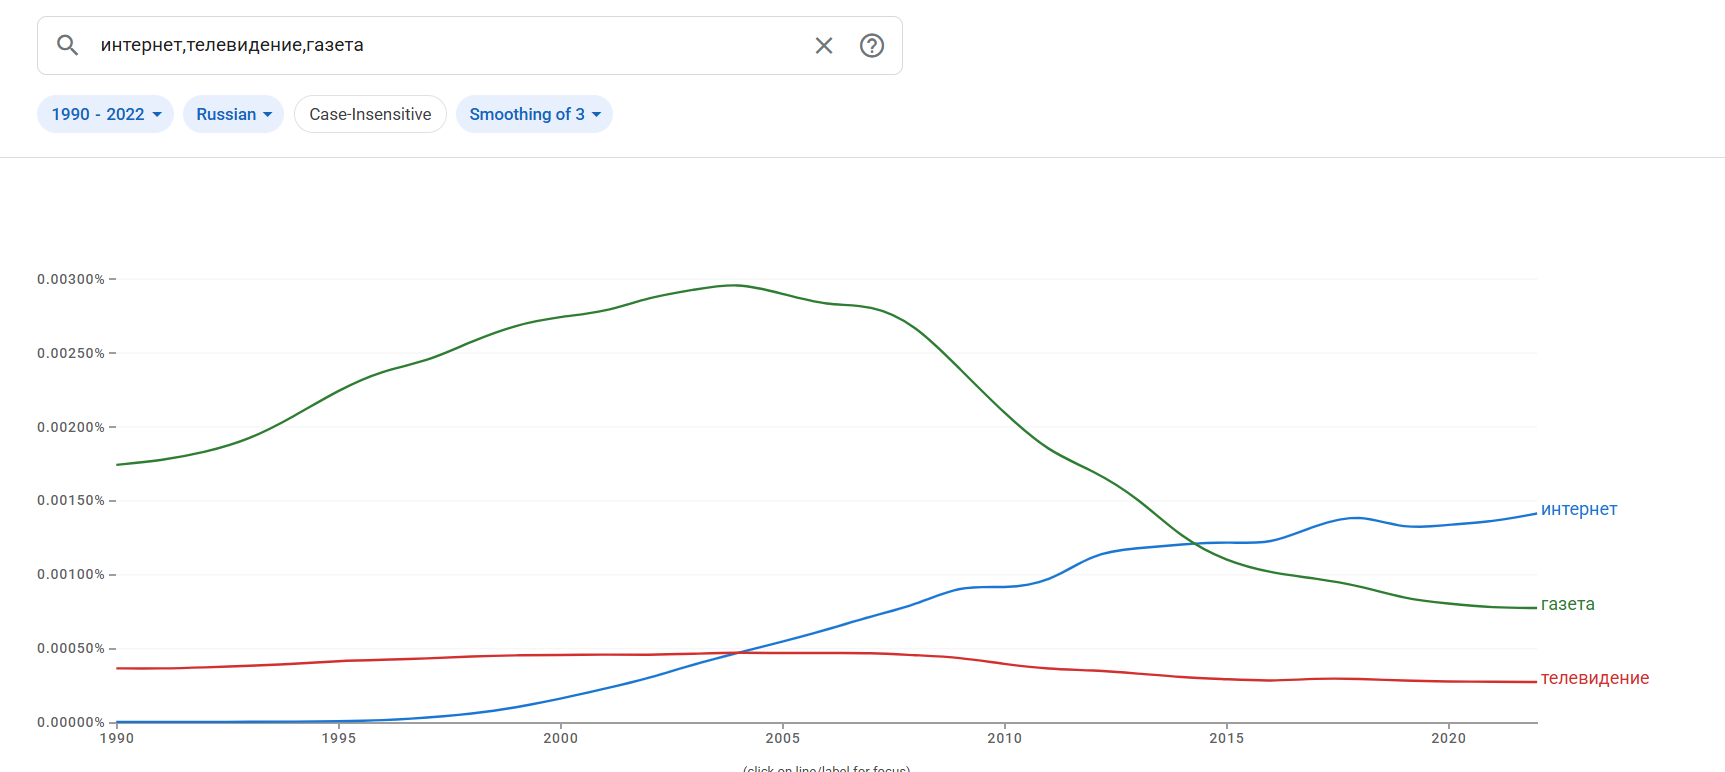

## Заданиe 3 (1 балл)

В семинаре мы использовали Dice coefficient (`score = 2 * bigram_count/((word_count_a+word_count_b))`) для нахождения коллокаций. 
Но самая известная метрика для этого другая - [PMI](https://en.wikipedia.org/wiki/Pointwise_mutual_information). Имплементируйте скоринг с помощью этой метрики и сравните результаты с Dice на топ 30 биграмах. 
Используйте логарифмы для работы с вероятностями. 

In [6]:
flat_tokens = list(chain.from_iterable(sent_tokens))

n = 2 # биграммы
bigrams = []
for sent in tqdm(sent_tokens):
    bigrams.extend(ngrams(sent, n))

100%|██████████| 76344/76344 [00:00<00:00, 97024.41it/s] 


In [7]:
unigram_freq = Counter(flat_tokens)
bigram_freq = Counter(bigrams)

N_tokens = sum(unigram_freq.values()) # все токены
N_bigrams = sum(bigram_freq.values()) # все биграммы

In [8]:
def scorer_pmi(bigram_count, word_count_a, word_count_b, n_tokens, n_bigrams):
    try:
        p_ab = bigram_count / n_bigrams
        p_a = word_count_a / n_tokens
        p_b = word_count_b / n_tokens
        score = math.log2(p_ab / (p_a * p_b))
    except (ZeroDivisionError, ValueError):
        return 0
    return score

def scorer_dice(bigram_count, word_count_a, word_count_b):
    try:
        score = 2 * bigram_count / (word_count_a + word_count_b)
    except ZeroDivisionError:
        return 0
    return score

In [9]:
MIN_COUNT = 10 # ограничение по частоте биграмм

dice_scores = {}
pmi_scores = {}

for (a, b), count in bigram_freq.items():
    if count < MIN_COUNT:
        continue
    dice_scores[(a, b)] = scorer_dice(count, unigram_freq[a], unigram_freq[b])
    pmi_scores[(a, b)] = scorer_pmi(count, unigram_freq[a], unigram_freq[b], N_tokens, N_bigrams)


In [10]:
top_30_dice = sorted(dice_scores.items(), key=lambda x: x[1], reverse=True)[:30]
top_30_pmi = sorted(pmi_scores.items(), key=lambda x: x[1], reverse=True)[:30]

In [11]:
top_30_dice

[(('della', 'sera'), 1.0),
 (('philip', 'morris'), 1.0),
 (('at', 't'), 1.0),
 (('стихийных', 'бедствий'), 1.0),
 (('mein', 'kampf'), 1.0),
 (('брюшного', 'тифа'), 1.0),
 (('риа', 'новости'), 0.9857806560608193),
 (('dow', 'jones'), 0.9824561403508771),
 (('wall', 'street'), 0.9811320754716981),
 (('exit', 'polls'), 0.9803921568627451),
 (('норильский', 'никель'), 0.96),
 (('пит', 'сампрас'), 0.9565217391304348),
 (('мысе', 'канаверал'), 0.9523809523809523),
 (('брюшным', 'тифом'), 0.9523809523809523),
 (('саудовской', 'аравии'), 0.9512195121951219),
 (('саудовская', 'аравия'), 0.9473684210526315),
 (('голден', 'ада'), 0.9473684210526315),
 (('new', 'york'), 0.9383886255924171),
 (('corriere', 'della'), 0.9375),
 (('часовым', 'механизмом'), 0.9333333333333333),
 (('северном', 'кавказе'), 0.930323846908734),
 (('ak', 'm'), 0.9259259259259259),
 (('associated', 'press'), 0.9254571026722925),
 (('подписные', 'листы'), 0.9230769230769231),
 (('интенсивной', 'терапии'), 0.9090909090909091),

In [12]:
top_30_pmi

[(('mein', 'kampf'), 17.231502353426244),
 (('мысе', 'канаверал'), 17.09399882967631),
 (('стихийных', 'бедствий'), 17.09399882967631),
 (('брюшным', 'тифом'), 17.09399882967631),
 (('интенсивной', 'терапии'), 16.96846794759245),
 (('at', 't'), 16.96846794759245),
 (('пит', 'сампрас'), 16.96846794759245),
 (('ясиром', 'арафатом'), 16.852990730172515),
 (('burger', 'king'), 16.852990730172515),
 (('ломоносовский', 'фарфоровый'), 16.830964423842516),
 (('полевыми', 'командирами'), 16.746075526256003),
 (('bp', 'amoco'), 16.705433541758655),
 (('ясир', 'арафат'), 16.64653985270509),
 (('assigned', 'names'), 16.646539852705086),
 (('алкогольного', 'опьянения'), 16.58995632433872),
 (('часовым', 'механизмом'), 16.553430448313605),
 (('прожиточного', 'минимума'), 16.50903632895515),
 (('drudge', 'report'), 16.50506742675221),
 (('corriere', 'della'), 16.465967607063266),
 (('della', 'sera'), 16.465967607063266),
 (('climate', 'orbiter'), 16.465967607063266),
 (('строуб', 'тэлботт'), 16.46596

### Результаты
#### Только dice
риа новости, dow jones, wall street, exit polls, норильский никель, саудовской аравии, саудовская аравия, голден ада, new york, северном кавказе, ak m, associated press, подписные листы, чрезвычайным ситуациям, polar lander, street journal, подписных листов
#### Только PMI
ясиром арафатом, burger king, ломоносовский фарфоровый, полевыми командирами, bp amoco, ясир арафат, assigned names, алкогольного опьянения, прожиточного минимума, drudge report, строуб тэлботт, северному кавказу, mci worldcom, lockheed martin, элла памфилова, линдсей дэвенпорт, соединенным штатам

Заметен перекос в сторону имен собственных у PMI. А ещё из-за отсутствия лемматизации разные формы попадают в список дважды (ясир арафат и ясиром арафатом)

# Задание 4 (2 балл)

Шаг 1: Измените функцию merge_round так чтобы она использовала скоринг, который вы сделаете в задании выше. 
Шаг 2: Подберите параметры (min_count, n_merges, n_rounds) так чтобы получались адекватные результаты
Шаг 3: Сохраните промежуточные словари мержей и напишите функцию, которая их последовательно применяет, чтобы иметь возможности воспроизвести трансформацию на любой новом тексте 

Подберите несколько предложений, на которых функция трансформации будет склеивать хотя бы несколько слов вместе 

In [13]:
def merge_round(corpus, min_count=5, n_merges=1000):
    """Один раунд BPE-подобного слияния по PMI"""
    u = Counter(t for s in corpus for t in s)
    b = Counter()
    for s in corpus:
        b.update(zip(s, s[1:]))

    n_tokens = sum(u.values())
    n_bigrams = sum(b.values())

    scores = {}
    for (w1, w2), c in b.items():
        if c >= min_count:
            scores[(w1, w2)] = scorer_pmi(c, u[w1], u[w2], n_tokens, n_bigrams)

    best = set(sorted(scores, key=scores.get, reverse=True)[:n_merges])

    merged = []
    for s in corpus:
        ws = []
        i = 0
        while i < len(s):
            if i < len(s) - 1 and (s[i], s[i + 1]) in best:
                ws.append("_".join((s[i], s[i + 1])))
                i += 2
            else:
                ws.append(s[i])
                i += 1
        merged.append(ws)

    merge_list = sorted(scores, key=scores.get, reverse=True)[:n_merges]
    return merged, merge_list

In [14]:
config = {"min_count": 5, "n_merges": 500, "n_rounds": 9}

sub_corpus = sent_tokens
saved_merges = []
for round_i in range(config["n_rounds"]):
        sub_corpus, merges = merge_round(sub_corpus, min_count=config["min_count"], n_merges=config["n_merges"])
        if not merges:
            break
        saved_merges.append(merges)

In [15]:
def apply_merges(text, saved_merges):
    single = isinstance(text[0], str)
    sentences = [text] if single else text

    for merges in saved_merges:
        best = set(merges)
        new_sentences = []
        for s in sentences:
            new_s = []
            i = 0
            while i < len(s):
                if i + 1 < len(s) and (s[i], s[i+1]) in best:
                    new_s.append(s[i] + "_" + s[i+1])
                    i += 2
                else:
                    new_s.append(s[i])
                    i += 1
            new_sentences.append(new_s)
        sentences = new_sentences

    return sentences[0] if single else sentences


In [16]:
test_sentences = [
    "На 35-й минуте Джузеппе Кардоне свалил в своей штрафной Индзаги, и Алессандро Дель Пьеро реализовал пятый пенальти в чемпионате.",
    "Источники в администрации президента Клинтона сообщили корреспонденту CNN о том, что известный международный террорист Осама бин Ладен в настоящее время занят подготовкой серии терактов против граждан США за пределами Северной Америки.",
    "Как сообщает РИА \"Новости\" со ссылкой на Минюст, в документе предлагается \"направить усилия на пресечение попыток привнесения элементов политического экстремизма в избирательный процесс\".",
]

for sent in test_sentences:
    tok = word_tokenize(sent)
    tok = [t.lower() for t in tok if re.fullmatch(r'\w+', t)]
    transformed = apply_merges(tok, saved_merges)
    print(f"Оригинал: {sent}")
    print(f"Токены до:{tok}")
    print(f"Токены после: {transformed}\n")

Оригинал: На 35-й минуте Джузеппе Кардоне свалил в своей штрафной Индзаги, и Алессандро Дель Пьеро реализовал пятый пенальти в чемпионате.
Токены до:['на', 'минуте', 'джузеппе', 'кардоне', 'свалил', 'в', 'своей', 'штрафной', 'индзаги', 'и', 'алессандро', 'дель', 'пьеро', 'реализовал', 'пятый', 'пенальти', 'в', 'чемпионате']
Токены после: ['на', 'минуте', 'джузеппе', 'кардоне', 'свалил', 'в', 'своей', 'штрафной', 'индзаги', 'и', 'алессандро_дель_пьеро', 'реализовал', 'пятый', 'пенальти', 'в', 'чемпионате']

Оригинал: Источники в администрации президента Клинтона сообщили корреспонденту CNN о том, что известный международный террорист Осама бин Ладен в настоящее время занят подготовкой серии терактов против граждан США за пределами Северной Америки.
Токены до:['источники', 'в', 'администрации', 'президента', 'клинтона', 'сообщили', 'корреспонденту', 'cnn', 'о', 'том', 'что', 'известный', 'международный', 'террорист', 'осама', 'бин', 'ладен', 'в', 'настоящее', 'время', 'занят', 'подготовк

# Задание 5 (3 балла)

Напишите краткое эссе (30 - 50 предложений) в свободной форме по одной из этих статей:
1) https://news.microsoft.com/source/2026/09/09/aft-uft-and-microsoft-announce-national-ai-safety-privacy-standard-for-schools-to-protect-students-families-and-educators/ и сам целый документ https://www.aft.org/sites/default/files/media/documents/2026/NAfAI-School_AI_Privacy_Standards.pdf
2) https://bayareacurrent.com/theres-a-lot-of-cleaning-up-poop-a-depot-worker-on-the-human-labor-behind-waymos-autonomous-vehicles/

Эту часть достаточно сложно оценивать формально, но я ожидаю увидеть ваши содержательные рассуждения о написанном в статье.   
Если после прочтения вам ничего не приходит в голову, то вы можете начать со следующих вопросов: Считаете ли вы эту информацию важной/интересной/страшной/скучной/и тп? Что показалось вам наиболее важным? Почему? Считаете ли вы эту статью объективной? Какие пробелы вы видите? По вашему мнению будет ли продолжение у этих историй? В каком направлении они будут развиваться? Считаете ли вы age restriction необходимым для AI моделей? (для первой статьи) Как можно предотвращать/бороться с подобным антисоциальным поведением в автономных автомобилях? (для второй) ... 
Но это не полный и не обязательный список! Вы можете писать о всем, что вы посчитаете нужным. 

Чего точно следует избегать:
1) Не пишите саммари! Ваше эссе должно выражать ваши собственные мысли и добавлять что-то к тексту, а не заменять его.
2) Не гонитесь за полнотой! Можно и нужно опускать детали. Вы даже можете даже сфокусироваться только на каком-то одном аспекте статьи и порассуждать о нем поглубже.
3) Не отвлекайтесь на форматирование! Не используйте нумерованные списки, булет пойнты, ссылки и т.п. Напишите все как один связанный plain текст (можете разбить все на параграфы, но не более того)
4) Не объясняйте термины и понятия, не давайте определений! Считайте, что читатель знает столько же, сколько вы или же что он может погуглить.
5) Не уходите от темы! Реагируйте только на сам текст, а не на общий контекст (схожие события и работы, реакция в сотсетях и т.п). Не сравнивайте с другими статьями от того же Антропика или OpenAI.
6) Не бойтесь выражать мнение! Но либо обосновывайте его, либо описиваете свои ощущения в деталях.
7) Будьте осторожными с bias. Не списывайте все на капитализм, AI buble, AI doomerism, AI accerationalism и тому подобные слишком общие и абстрактные вещи. Не выражайте ваше личное отношение к авторам (антропику), только к содержанию статьи! 



Часто мы как компьютерные лингвисты работаем с моделями в в академическом режиме. В нем встреча модели с реальным миром, например, оценка на бенчмарке, во-первых, контролируема, а во-вторых, отделена от момента, когда с моделью взаимодействует живой человек, в третьих, цена ошибки не слишком велика. Для AV ошибка модели может значить необратимое изменение реального мира. В этом эссе я размышляю про то, как работает AI (и в том числе оценка его качества) не в тепличной научной среде, где честность — это метод, а в бизнесе. 

Я привыкла мыслить модель как объект с фиксированным (в случае оценки в бенчмарке) инпутом и аутпутом: подается пример, получается ответ, сравнивается с эталоном. В городе инпут не фиксирован, а среда каким-то образом реагирует на действия модели. Например, если автомобиль встаёт в узком проезде, другие машины меняют траекторию, люди сигналят. Ошибка системы меняет саму среду, в которой её поведение оценивается, возникает некоторая рекурсия.

У вождения нет и не может быть настоящего бенчмарка в строгом смысле. У закрытой задачи обычно есть формально проверяемый ответ, но у решения, принятого автомобилем в конкретную секунду — нет. Ререшие оценивается от обратного: не «это правильно», а «это НЕ неправильно». Решить, было ли решение верным, можно либо дождавшись исхода (и приемлемым исходом, единственным, который можно формализовать, оказывается авария) либо сравнив с альтернативой, которой не случилось. Сами Waymo признают это открытой проблемой: удовлетворительного набора метрик для сравнения AV с человеком-водителем пока не существует.

Тогда как оценивать качество? В отсутствии бенчмарка индустрия хватается за то, что вообще можно посчитать. Сначала это была частота disengagements — как часто система передаёт управление человеку. Чем реже просит о помощи, тем надёжнее. Но как только цифра становится единственным доказательством прогресса перед клиентом, она перестает быть метрикой. Сравните рассказ из интервью про то, что застрявшую в заторе машину специально не отключают подольше, не потому что это разумно инженерно, а чтобы дать системе шанс разобраться самой, а потому что отключение портит именно ту метрику, по которой судили о прогрессе всей технологии. Получается парадокс: если вмешательство предотвращает опасную ситуацию, оно одновременно улучшает результат и ухудшает статистику автономности. Если вмешательство запрещают ради красивой цифры, показатель перестает описывать способность системы понимать дорогу — типичный Goodhart's Law, мера, ставшая целью, перестаёт быть хорошей мерой. Конечно, целью её делает не абстрактная оптимизация, а конкретная нужда отчитаться о качестве при отсутствии другого способа это сделать. Похожая динамика знакома и в работе с языковыми моделями, но там почти всегда есть доступная, просто менее выгодная честная альтернатива. У AV её как будто в целом нет: суррогатная метрика была единственным способом хоть что-то измерить.

Слабость системы при находится не только там, где работает метрика, будь то disengagement или crash rate. Публичный образ AV-неудачи предполагает ошибку восприятия — модель “не увидела” препятствие. Но история с автомобилями, зависающими друг напротив друга, когда оба корректно «видят» друг друга, но не имеют протокола координации между собой, — показывает, что провал может быть не в качестве нейросети, а в связи между агентами и вообще связях элементов системы между собой. Метрики вроде disengagement или crash rate измеряют именно ошибки конкретного автомобиля. Происходит оптимизация работы одной ячейки системы, хотя должна происходить оптимизация системы целиком.

Всё больше AI-компаний стремятся к хотя бы показательной прозрачности — публикуют safety-отчёты с оговорками, признают ограничения собственных метрик. Но часто это выглядит не как альтернатива пиару, а его более тонкая форма. Раскрывается то, что уже нельзя скрыть, и подаётся это максимально ответственным тоном. Саморазоблачение становится способом поднять себе цену.

Видимо, в привычной мне науке это обязательство внешнего контроля данных и результатов встроено в процедуру рецензирования. В бизнесе оно появляется только под внешним давлением. Наверное, поэтому честность там почти никогда не выглядит как научная честность — она выглядит как хорошо срежиссированный жест.
